# Funciones de Activación: la no linealidad que lo cambia todo
**Basado en**: *Neural Networks from Scratch* - Capítulo 4 (Activation Functions)

**Objetivo**: entender por que las funciones de activación son imprescindibles
y como ReLU y Softmax hacen posible que las redes aprendan problemas complejos.

**La pregunta clave**: ¿por qué una red de 10 capas lineales no es mejor que una de 1?

**Estructura del notebook:**
1. Sin activación: el problema de la linealidad
2. Funciones históricas: Step y Sigmoid
3. ReLU: simple, eficaz, dominante
4. Como ReLU aproxima funciones no lineales
5. Softmax: convertir logits en probabilidades
6. Pipeline completo: Dense → ReLU → Dense → Softmax
7. Ejercicio de decisión

---

In [1]:
%pip install -q nnfs

import numpy as np
import matplotlib.pyplot as plt
import nnfs
from nnfs.datasets import spiral_data
import os

nnfs.init()
os.makedirs('images', exist_ok=True)
%matplotlib inline
print(f'NumPy {np.__version__}')
print('[OK] Entorno listo')


Note: you may need to restart the kernel to use updated packages.
NumPy 1.26.4
[OK] Entorno listo


In [2]:
# Clase Layer_Dense del B03B - la necesitamos para los ejemplos

class Layer_Dense:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases  = np.zeros((1, n_neurons))

    def forward(self, inputs):
        self.output = np.dot(inputs, self.weights) + self.biases

print('[OK] Layer_Dense definida')

[OK] Layer_Dense definida


---
## 1. Sin activación: el colapso lineal

¿Qué pasa si apilamos capas densas sin ninguna función de activación?

Una capa densa es una transformación lineal: `output = X @ W + b`.
Si aplicamos dos capas lineales seguidas:

```
capa2(capa1(X)) = W2 @ (W1 @ X + b1) + b2
               = (W2 @ W1) @ X + (W2 @ b1 + b2)
               = W_efectiva @ X + b_efectiva
```

**Dos capas lineales son matemáticamente equivalentes a una sola capa lineal.**

No importa cuántas capas apilemos: si son todas lineales,
la red entera colapsa a una única transformación lineal.
La profundidad no aporta nada sin no linealidad.

La función de activación **rompe** este colapso al introducir una operación no lineal
entre capas.

In [3]:
# Demostracion del colapso lineal

np.random.seed(42)
X = np.random.randn(5, 3)  # 5 muestras, 3 features

# Dos capas lineales
W1 = np.random.randn(3, 4)
b1 = np.random.randn(1, 4)
W2 = np.random.randn(4, 2)
b2 = np.random.randn(1, 2)

# Forward pass con dos capas
h1  = X @ W1 + b1
out = h1 @ W2 + b2

# Matrices equivalentes combinadas
W_efectiva = W1 @ W2
b_efectiva = b1 @ W2 + b2
out_equivalente = X @ W_efectiva + b_efectiva

print('Son identicos? (tolerancia numerica):')
print(np.allclose(out, out_equivalente))
print()
print('Diferencia maxima:', np.max(np.abs(out - out_equivalente)))
print()
print('Conclusion: 2 capas lineales = 1 sola capa lineal equivalente.')
print('La profundidad sin activacion no lineales no añade capacidad de representacion.')

Son identicos? (tolerancia numerica):
True

Diferencia maxima: 4.7683716e-07

Conclusion: 2 capas lineales = 1 sola capa lineal equivalente.
La profundidad sin activacion no lineales no añade capacidad de representacion.


---
## 2. Funciones históricas: Step y Sigmoid

### Step function (función escalón)
La más simple: si la entrada es > 0, salida = 1; si no, salida = 0.
Imita el comportamiento biológico de un neuron que "dispara o no dispara".

**Problema**: no da información de cuanto se alejó del umbral.
Un input de 0.001 y uno de 1000 producen el mismo output: 1.
El optimizador no puede aprender bien con esto.

### Sigmoid (función logística)
```
sigmoid(x) = 1 / (1 + e^(-x))
```
Devuelve valores en (0, 1). Más informativa que el escalón:
el output refleja cuánto se alejó de cero.

**Problema**: para valores grandes/pequeños de x, el gradiente se acerca a 0
(*vanishing gradient problem*). Las redes profundas aprenden muy lento.
Hoy se usa principalmente en la capa de salida de clasificadores binarios.

Ambas fueron los estándares históricos. Desde ~2012, **ReLU** las reemplaza
en capas ocultas.

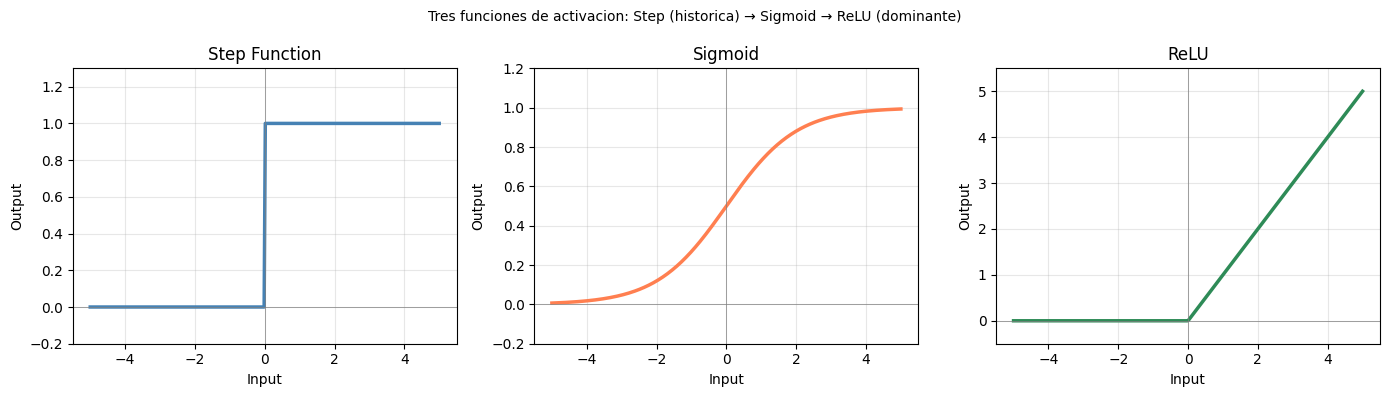

In [4]:
# Visualizacion de Step, Sigmoid y ReLU

x = np.linspace(-5, 5, 300)

# Step function
def step(x):
    return (x > 0).astype(float)

# Sigmoid
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# ReLU
def relu(x):
    return np.maximum(0, x)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, func, nombre, color in zip(
    axes,
    [step, sigmoid, relu],
    ['Step Function', 'Sigmoid', 'ReLU'],
    ['steelblue', 'coral', 'seagreen']
):
    ax.plot(x, func(x), color=color, linewidth=2.5)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_title(nombre, fontsize=12)
    ax.set_xlabel('Input')
    ax.set_ylabel('Output')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.2, 1.2)

axes[0].set_ylim(-0.2, 1.3)
axes[2].set_ylim(-0.5, 5.5)

plt.suptitle('Tres funciones de activacion: Step (historica) → Sigmoid → ReLU (dominante)', fontsize=10)
plt.tight_layout()
plt.savefig('images/B03C_fig01.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close('all')

### Por qué la función escalón es inutilizable para entrenar redes neuronales?

La **función escalón** (o función de Heaviside) es intuitivamente perfecta:
imita exactamente como funciona una neurona biológica: dispara (1) o no dispara (0).
Sin embargo, tiene un defecto estructural que la hace inutilizable en el
entrenamiento por **backpropagation** (retropropagación del error).

**El problema: su derivada es cero en casi todo su dominio.**

Cuando entrenamos una red, backpropagation necesita calcular el gradiente de la
pérdida respecto a cada peso. Para ello aplica la **regla de la cadena** capa por capa:

```
dL/dw = dL/dy * dy/dz * dz/dw
        errores  activacion  peso
```

El término `dy/dz` es la **derivada de la función de activación**. Si esa derivada
es cero, el gradiente se anula: el peso **no se mueve**. La red no aprende.

La función escalón tiene:
- Derivada = **0** en todo x diferente de 0
- Derivada = **indefinida** (discontinuidad) en x = 0

Es decir, el gradiente no puede fluir hacia atrás: backpropagation queda bloqueado.

**La solución: funciones suaves y derivables**

La **sigmoide** s(x) = 1 / (1 + e^-x) tiene exactamente la misma forma de 'S'
que la función escalón, pero es **continua y diferenciable en todo su dominio**.
Su derivada tiene una forma analítica elegante: s'(x) = s(x) * (1 - s(x)).
Siempre calculable, siempre no nula en la zona activa -> el gradiente fluye.

Otras funciones derivables con comportamiento similar en los extremos:

| Función | Fórmula | Ventaja | Limitación |
|---|---|---|---|
| **Sigmoide** | 1/(1+e^-x) | Diferenciable, acotada [0,1] | Gradientes pequeños en extremos (*vanishing gradient*) |
| **tanh** | (e^x - e^-x)/(e^x + e^-x) | Centrada en 0, acotada [-1,1] | También sufre vanishing gradient |
| **ReLU** | max(0,x) | Derivada = 1 cuando x>0, sin saturación | Neuronas muertas si x<0 siempre |
| **Leaky ReLU** | max(0.01x, x) | Evita neuronas muertas | Menos interpretable |

La figura siguiente muestra visualmente el problema:
compara la función escalón y la sigmoide junto a sus derivadas.

In [5]:
# Comparativa: funcion escalon vs sigmoide + sus derivadas (2x2)
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import pathlib

IMG = pathlib.Path('images')
IMG.mkdir(exist_ok=True)

x = np.linspace(-6, 6, 1000)


def step_fn(x):
    return (x >= 0).astype(float)


def sigmoid_fn(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))


def step_deriv(x):
    """Derivada de step: 0 en casi todo el dominio, NaN en x=0."""
    d = np.zeros_like(x)
    d[np.abs(x) < 0.02] = np.nan
    return d


def sigmoid_deriv(x):
    """Derivada analitica: s(x) * (1 - s(x))."""
    s = sigmoid_fn(x)
    return s * (1 - s)


fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Funcion escalon vs Sigmoide: la derivada lo cambia todo',
             fontsize=13, fontweight='bold', y=1.01)

# Panel 1: Step
ax = axes[0, 0]
ax.plot(x, step_fn(x), color='#C0392B', linewidth=2.5, label='Step(x)')
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_title('Funcion escalon  Step(x)', fontsize=11)
ax.set_ylabel('Salida', fontsize=9)
ax.set_ylim(-0.2, 1.3)
ax.set_xlim(-6, 6)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
ax.annotate('Salto brusco\nen x=0', xy=(0, 0.5), xytext=(1.5, 0.8),
            arrowprops=dict(arrowstyle='->', color='#555'),
            fontsize=9, color='#C0392B')

# Panel 2: Sigmoid
ax = axes[0, 1]
ax.plot(x, sigmoid_fn(x), color='#2980B9', linewidth=2.5, label='sigmoid(x)')
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_title('Sigmoide  s(x) = 1/(1 + e^-x)', fontsize=11)
ax.set_ylabel('Salida', fontsize=9)
ax.set_ylim(-0.2, 1.3)
ax.set_xlim(-6, 6)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
ax.annotate('Transicion suave\nen x=0', xy=(0, 0.5), xytext=(1.5, 0.8),
            arrowprops=dict(arrowstyle='->', color='#555'),
            fontsize=9, color='#2980B9')

# Panel 3: Derivada de Step
ax = axes[1, 0]
d_step = step_deriv(x)
ax.plot(x, d_step, color='#C0392B', linewidth=2.5, label="Step'(x)", zorder=3)
ax.axvline(0, color='#C0392B', linewidth=1, linestyle=':', alpha=0.7)
ax.scatter([0], [0], color='#C0392B', s=60, zorder=5, marker='x',
           linewidth=2.5, label='indefinida en x=0')
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_title("Derivada de Step: Step'(x)", fontsize=11)
ax.set_ylabel('Gradiente', fontsize=9)
ax.set_xlabel('x', fontsize=9)
ax.set_ylim(-0.3, 1.0)
ax.set_xlim(-6, 6)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
ax.text(0, 0.55,
        'Derivada = 0 en casi todo\n  -> gradiente no fluye\n  -> la red no aprende',
        fontsize=8.5, color='#C0392B',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#FDEDEC', edgecolor='#C0392B'),
        ha='center', va='bottom')

# Panel 4: Derivada de Sigmoid
ax = axes[1, 1]
d_sig = sigmoid_deriv(x)
ax.plot(x, d_sig, color='#2980B9', linewidth=2.5, label="s'(x) = s(x)*(1-s(x))")
ax.fill_between(x, d_sig, alpha=0.12, color='#2980B9')
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_title("Derivada de Sigmoide: s'(x)", fontsize=11)
ax.set_ylabel('Gradiente', fontsize=9)
ax.set_xlabel('x', fontsize=9)
ax.set_ylim(-0.05, 0.32)
ax.set_xlim(-6, 6)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
ax.annotate("Max = 0.25\nen x=0", xy=(0, 0.25), xytext=(1.8, 0.26),
            arrowprops=dict(arrowstyle='->', color='#555'),
            fontsize=9, color='#2980B9')
ax.text(0, 0.07,
        'Siempre calculable\n  -> backprop funciona\n  -> la red aprende',
        fontsize=8.5, color='#1A5276',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#EBF5FB', edgecolor='#2980B9'),
        ha='center', va='bottom')

plt.tight_layout()
plt.savefig(IMG / 'B03C_fig04.png', dpi=130, bbox_inches='tight')
plt.close()
print("Guardado: B03C_fig04.png")

vals = np.array([-5., -1., 0., 1., 5.])
print("\nDerivada Step en x=[-5,-1,0,1,5]:", step_deriv(vals))
print("Derivada Sigmoid en x=[-5,-1,0,1,5]:", sigmoid_deriv(vals).round(4))
print("\nConclusión: sigmoid siempre tiene derivada calculable")
print("           -> backpropagation puede propagar el gradiente en toda la red")

Guardado: B03C_fig04.png

Derivada Step en x=[-5,-1,0,1,5]: [ 0.  0. nan  0.  0.]
Derivada Sigmoid en x=[-5,-1,0,1,5]: [0.0066 0.1966 0.25   0.1966 0.0066]

Conclusión: sigmoid siempre tiene derivada calculable
           -> backpropagation puede propagar el gradiente en toda la red


---
## 3. ReLU: Rectified Linear Unit

```
ReLU(x) = max(0, x)
```

Extremadamente simple: si el input es positivo, lo deja pasar; si es negativo, lo clipa a 0.

**Por qué funciona tan bien**:
- Introduce no linealidad con el punto de ruptura en 0
- El gradiente es 1 para valores positivos → no hay vanishing gradient
- Muy rápida de computar
- Crea "areas de efecto": cada neurona se activa solo para ciertos patrones de entrada

**Neurona muerta** (*dead neuron*):
Si un peso queda muy negativo, ReLU siempre devuelve 0 para esa neurona.
El gradiente también es 0 → el peso nunca se actualiza.
Solución habitual: usar un learning rate moderado o Leaky ReLU.

En el libro NNFS (y en PyTorch/TensorFlow), ReLU es la activación por defecto
para capas ocultas desde hace más de una década.

In [6]:
# ReLU - tres implementaciones equivalentes

inputs = [0, 2, -1, 3.3, -2.7, 1.1, 2.2, -100]

# 1. Con condicional explícito
output_if = []
for i in inputs:
    if i > 0:
        output_if.append(i)
    else:
        output_if.append(0)

# 2. Con max()
output_max = [max(0, i) for i in inputs]

# 3. Con NumPy (la forma eficiente)
output_np = np.maximum(0, inputs)

print('Input:       ', inputs)
print('Con if:      ', output_if)
print('Con max:     ', output_max)
print('Con NumPy:   ', output_np)
print()
print('Todos identicos:', (output_if == output_max) and np.allclose(output_np, output_max))

Input:        [0, 2, -1, 3.3, -2.7, 1.1, 2.2, -100]
Con if:       [0, 2, 0, 3.3, 0, 1.1, 2.2, 0]
Con max:      [0, 2, 0, 3.3, 0, 1.1, 2.2, 0]
Con NumPy:    [0.  2.  0.  3.3 0.  1.1 2.2 0. ]

Todos identicos: True


In [7]:
# Clase Activation_ReLU - siguiendo el patron del libro NNFS

class Activation_ReLU:
    # Forward pass
    def forward(self, inputs):
        # Clip a 0 los valores negativos
        self.output = np.maximum(0, inputs)


# Verificacion con datos espirales
X, y = spiral_data(samples=100, classes=3)

dense1     = Layer_Dense(2, 3)
activation1 = Activation_ReLU()

dense1.forward(X)
activation1.forward(dense1.output)

print('Output de la capa densa (puede tener negativos):')
print(dense1.output[:5])
print()
print('Output tras ReLU (solo ceros y positivos):')
print(activation1.output[:5])
print()
print('Minimo antes de ReLU:', dense1.output.min())
print('Minimo tras  ReLU:   ', activation1.output.min(), ' <- siempre >= 0')

Output de la capa densa (puede tener negativos):
[[ 0.0000000e+00  0.0000000e+00  0.0000000e+00]
 [-4.6472578e-05  2.4485800e-05 -1.4834548e-04]
 [-9.2500581e-05  4.9362650e-05 -2.9742360e-04]
 [-1.6057276e-04  3.2367836e-05 -3.3281077e-04]
 [-1.8579085e-04  9.8031567e-05 -5.9354887e-04]]

Output tras ReLU (solo ceros y positivos):
[[0.0000000e+00 0.0000000e+00 0.0000000e+00]
 [0.0000000e+00 2.4485800e-05 0.0000000e+00]
 [0.0000000e+00 4.9362650e-05 0.0000000e+00]
 [0.0000000e+00 3.2367836e-05 0.0000000e+00]
 [0.0000000e+00 9.8031567e-05 0.0000000e+00]]

Minimo antes de ReLU: -0.014443895
Minimo tras  ReLU:    0.0  <- siempre >= 0


---
## 4. Cómo ReLU aproxima funciones no lineales

Cada par de neuronas con ReLU puede modelar una "área de efecto":
un segmento de función con forma de rampa.

```
Neurona 1 (w=+1, b=-0.3):  activa cuando x > 0.3   (determina cuando empieza)
Neurona 2 (w=-1, b=+0.7):  activa cuando x < 0.7   (determina cuando termina)
                            juntas forman un "pulso" entre 0.3 y 0.7
```

Con 8 pares de neuronas y 2 capas ocultas, la red puede aproximar
funciones complejas como `sin(x)` o las espirales de clasificación.

**Intuición geométrica**: cada neurona ReLU "dobla" el espacio de datos
en un punto. Más neuronas = más dobleces = más capacidad de representación.

La linealidad tiene cero dobleces. Sigmoid/Step tienen uno (suave/brusco).
ReLU tiene un doblez agudo en 0 - simple pero suficiente cuando hay muchas.

In [8]:
# Visualizacion: la misma red lineal vs no lineal (con ReLU) en datos espirales
# Mostramos las distribuciones de activacion tras la capa 1

X, y = spiral_data(samples=100, classes=3)
colores = ['steelblue', 'coral', 'seagreen']

dense1_relu = Layer_Dense(2, 8)    # capa oculta de 8 neuronas
act1_relu   = Activation_ReLU()

dense1_relu.forward(X)
act1_relu.forward(dense1_relu.output)

fig, axes = plt.subplots(2, 4, figsize=(16, 6))

for i in range(8):
    ax = axes[i // 4][i % 4]
    for clase in range(3):
        mask = y == clase
        ax.hist(act1_relu.output[mask, i], bins=20, alpha=0.5,
                color=colores[clase], label=f'c{clase}')
    ax.set_title(f'Neurona {i+1} (ReLU)')
    ax.set_xlabel('Activacion')
    if i % 4 == 0:
        ax.set_ylabel('Frecuencia')
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=7)

plt.suptitle('Activaciones ReLU de 8 neuronas ocultas (pesos aleatorios)\n'
             'Nota: muchos ceros - neurona inactiva para esas muestras', fontsize=10)
plt.tight_layout()
plt.savefig('images/B03C_fig02.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close('all')

fraccion_ceros = (act1_relu.output == 0).mean()
print(f'Fraccion de activaciones = 0: {fraccion_ceros:.1%}')
print('Esto es esperable con pesos aleatorios y ReLU.')

Fraccion de activaciones = 0: 50.7%
Esto es esperable con pesos aleatorios y ReLU.


C:\Users\amado\AppData\Local\Temp\ipykernel_168532\3149186369.py:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


---
## 5. Softmax: de logits a probabilidades

La capa de salida de un clasificador produce **logits**: números reales sin escala.
Por ejemplo: `[4.8, 1.21, 2.385]`

Para interpretarlos como probabilidades necesitamos:
1. Que todos sean no negativos (e^x siempre es > 0)
2. Que sumen 1 (normalización)

**Softmax** hace exactamente esto:
```
softmax(z_i) = exp(z_i) / sum(exp(z_j))   para todo j
```

**Estabilidad numérica**: `exp(1000)` produce overflow (infinito en float).
Solución: restar el máximo antes de exponenciar.
```
softmax(z_i) = exp(z_i - max(z)) / sum(exp(z_j - max(z)))
```
El resultado es matemáticamente idéntico pero numéricamente estable.

**Por qué Softmax en la capa de salida, no ReLU**:
- ReLU es independiente por neurona (no normaliza)
- Softmax hace que las probabilidades compitan y sumen 1
- Resultado interpretable: "el modelo tiene 89.5% de confianza en la clase 0"

In [9]:
# Softmax paso a paso - siguiendo el libro NNFS

E = 2.71828182846  # constante de Euler (tambien: math.e o np.e)

# Ejemplo: salidas de una capa para una sola muestra
layer_outputs = [4.8, 1.21, 2.385]

# Paso 1: exponenciar (garantiza no negativos)
exp_values = [E ** x for x in layer_outputs]
print('Valores exponenciados:', exp_values)

# Paso 2: normalizar (dividir por la suma = probabilidades)
norm_base = sum(exp_values)
norm_values = [v / norm_base for v in exp_values]
print('Probabilidades:       ', [f'{v:.4f}' for v in norm_values])
print('Suma de probabilidades:', sum(norm_values))

Valores exponenciados: [121.51041751893969, 3.3534846525504487, 10.85906266492961]
Probabilidades:        ['0.8953', '0.0247', '0.0800']
Suma de probabilidades: 1.0


In [10]:
# Softmax con NumPy - version vectorizada para batches

layer_outputs_np = np.array([4.8, 1.21, 2.385])

exp_vals  = np.exp(layer_outputs_np)
norm_vals = exp_vals / np.sum(exp_vals)
print('NumPy softmax:', norm_vals)
print('Suma:', np.sum(norm_vals))

print()
print('=== Problema de overflow con valores grandes ===')
print('np.exp(100)  =', np.exp(100))
print('np.exp(1000) =', np.exp(1000), '  <- overflow!')

print()
print('=== Solucion: restar el maximo (numericamente equivalente) ===')
x = np.array([1000, 1001, 1002])
x_estable = x - np.max(x)  # ahora: [-2, -1, 0]
exp_estable = np.exp(x_estable)
print('x estabilizado:', x_estable)
print('exp estabilizado:', exp_estable)
probs = exp_estable / np.sum(exp_estable)
print('Softmax estable:', probs)

NumPy softmax: [0.89528266 0.02470831 0.08000903]
Suma: 0.9999999999999999

=== Problema de overflow con valores grandes ===
np.exp(100)  = 2.6881171418161356e+43
np.exp(1000) = inf   <- overflow!

=== Solucion: restar el maximo (numericamente equivalente) ===
x estabilizado: [-2 -1  0]
exp estabilizado: [0.13533528 0.36787944 1.        ]
Softmax estable: [0.09003057 0.24472847 0.66524096]


C:\Users\amado\AppData\Local\Temp\ipykernel_168532\3475717763.py:13: RuntimeWarning: overflow encountered in exp
  print('np.exp(1000) =', np.exp(1000), '  <- overflow!')


In [11]:
# Clase Activation_Softmax - version para batches con estabilidad numerica

class Activation_Softmax:
    def forward(self, inputs):
        # Restar el maximo por fila para evitar overflow
        # keepdims=True mantiene shape (batch, 1) para broadcasting
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
        # Normalizar cada fila (muestra) para que sume 1
        probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True)
        self.output = probabilities


# Verificacion de que restar el maximo no cambia el resultado
sm = Activation_Softmax()

sm.forward(np.array([[1, 2, 3]]))
print('softmax([1, 2, 3]):', sm.output)

sm.forward(np.array([[-2, -1, 0]]))  # resto max=3, resultado identico
print('softmax([-2,-1, 0]):', sm.output, '  <- identico')

print()
print('Batch de 3 muestras:')
batch = np.array([[4.8, 1.21, 2.385],
                  [8.9, -1.81, 0.2],
                  [1.41, 1.051, 0.026]])
sm.forward(batch)
print(sm.output)
print('Sumas por fila:', np.sum(sm.output, axis=1))  # todas deben ser 1.0

softmax([1, 2, 3]): [[0.09003057 0.24472847 0.66524096]]
softmax([-2,-1, 0]): [[0.09003057 0.24472847 0.66524096]]   <- identico

Batch de 3 muestras:
[[8.95282664e-01 2.47083068e-02 8.00090293e-02]
 [9.99811129e-01 2.23163963e-05 1.66554348e-04]
 [5.13097164e-01 3.58333899e-01 1.28568936e-01]]
Sumas por fila: [1. 1. 1.]


---
## 6. Pipeline completo: Dense → ReLU → Dense → Softmax

Con todos los bloques definidos, construimos el pipeline de inferencia completo:

```
X           →  dense1  →  relu1  →  dense2  →  softmax2  →  probabilidades
(300, 2)      (2→3)      no-lin    (3→3)       suma=1
```

El output final es una matriz `(300, 3)` donde cada fila es una distribución
de probabilidad sobre las 3 clases: `[P(clase0), P(clase1), P(clase2)]`.

Con pesos aleatorios, estas probabilidades serán cercanas a `[0.33, 0.33, 0.33]`.
El entrenamiento (B03D + B04) las alejará de la uniformidad hacia las respuestas correctas.

In [12]:
# Pipeline completo: Dense -> ReLU -> Dense -> Softmax
# Codigo completo siguiendo el libro NNFS

import numpy as np
import nnfs
from nnfs.datasets import spiral_data

nnfs.init()

X, y = spiral_data(samples=100, classes=3)

# Capa 1: 2 features de entrada, 3 neuronas
dense1      = Layer_Dense(2, 3)
activation1 = Activation_ReLU()

# Capa 2 (salida): 3 entradas, 3 neuronas (una por clase)
dense2      = Layer_Dense(3, 3)
activation2 = Activation_Softmax()

# Forward pass completo
dense1.forward(X)
activation1.forward(dense1.output)

dense2.forward(activation1.output)
activation2.forward(dense2.output)

print('Primeras 5 predicciones (probabilidades por clase):')
print(activation2.output[:5])
print()
print('Clase predicha para cada muestra (argmax):')
predicciones = np.argmax(activation2.output, axis=1)
print('Primeras 10 predicciones:', predicciones[:10])
print('Primeras 10 etiquetas:   ', y[:10])
print()
accuracy = np.mean(predicciones == y)
print(f'Accuracy con pesos aleatorios: {accuracy:.3f}')
print('Esperado ~0.33 (azar con 3 clases)')

Primeras 5 predicciones (probabilidades por clase):
[[0.33333334 0.33333334 0.33333334]
 [0.3333332  0.3333332  0.33333364]
 [0.3333329  0.33333293 0.3333342 ]
 [0.3333326  0.33333263 0.33333477]
 [0.33333233 0.3333324  0.33333528]]

Clase predicha para cada muestra (argmax):
Primeras 10 predicciones: [0 2 2 2 2 2 2 2 2 2]
Primeras 10 etiquetas:    [0 0 0 0 0 0 0 0 0 0]

Accuracy con pesos aleatorios: 0.340
Esperado ~0.33 (azar con 3 clases)


In [13]:
# Visualizar: distribucion de probabilidades predichas (pesos aleatorios)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i in range(3):
    for clase in range(3):
        mask = y == clase
        axes[i].hist(activation2.output[mask, i], bins=20, alpha=0.5,
                     label=f'etiqueta {clase}', range=(0, 1))
    axes[i].set_title(f'P(clase {i}) predicha')
    axes[i].set_xlabel('Probabilidad')
    if i == 0:
        axes[i].set_ylabel('Frecuencia')
        axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Probabilidades predichas con pesos ALEATORIOS (sin entrenar)\n'
             'Todas las distribuciones se mezclan - el modelo no ha aprendido nada', fontsize=10)
plt.tight_layout()
plt.savefig('images/B03C_fig03.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close('all')

C:\Users\amado\AppData\Local\Temp\ipykernel_168532\1503875886.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


---
## 7. Ejercicio de decisión

### Caso: modelo de clasificación de documentos en la empresa

El equipo legal necesita clasificar contratos en 4 categorías:
- SaaS, Licencia perpetua, Servicio profesional, NDA

Un proveedor propone una red con:
- 3 capas ocultas con **Sigmoid** como función de activación
- Capa de salida con **ReLU**

---

**Pregunta 1 - La capa de salida**:
¿Es correcto usar ReLU en la capa de salida para clasificación multiclase?
¿Qué problema hay?

**Pregunta 2 - Sigmoid en capas ocultas**:
¿Por qué se reemplazó Sigmoid por ReLU en capas ocultas?
¿En qué situación podría seguir usando Sigmoid?

**Pregunta 3 - Número de salidas**:
¿Cuántas neuronas debe tener la capa de salida para este problema?

**Pregunta 4 - Alternativa**:
Propón la arquitectura correcta para este problema (capas, activaciones, dimensiones).

---
*Escribe tus respuestas en la celda siguiente.*

### Mis respuestas

**Pregunta 1 - La capa de salida:**

*(escribe aqui)*

**Pregunta 2 - Sigmoid en capas ocultas:**

*(escribe aqui)*

**Pregunta 3 - Número de salidas:**

*(escribe aqui)*

**Pregunta 4 - Arquitectura correcta:**

*(escribe aqui)*

---

<!--
CRITERIOS DE EVALUACIÓN (para el instructor)

Pregunta 1:
ReLU en la capa de salida de un clasificador es incorrecto:
- Devuelve valores >= 0, pero no normalizados (no suman 1)
- No se pueden interpretar como probabilidades de clase
- Softmax es la activación correcta para clasificación multiclase
Excepción: para clasificación binaria se puede usar Sigmoid (una sola salida).

Pregunta 2:
Sigmoid en capas ocultas tiene vanishing gradient:
- Para |x| > 4, el gradiente de sigmoid ≈ 0
- En redes profundas, los gradientes se multiplican capa a capa
- Con muchas capas Sigmoid, el gradiente de las primeras capas se extingue
- Resultado: las primeras capas no aprenden
Cuando seguir usando Sigmoid: capa de salida de clasificadores binarios.

Pregunta 3:
4 neuronas en la capa de salida (una por categoría: SaaS, Licencia, Servicio, NDA).
Penalizar: confundir el número de clases con el número de entradas.

Pregunta 4:
Arquitectura correcta:
  Input: n_features (depende de la representación del texto)
  Capa oculta 1: Dense(n_features, 64) + ReLU
  Capa oculta 2: Dense(64, 32) + ReLU   (opcional, según volumen de datos)
  Salida: Dense(32, 4) + Softmax
Respuesta que menciona Softmax en la salida y ReLU en ocultas = correcta.
Respuesta que no especifica la dimensión de salida = incompleta.
-->

---
## Puntos clave del B03C

1. **Sin activación no lineal, la red colapsa**: N capas lineales = 1 capa lineal.
   La profundidad solo tiene valor con funciones de activación no lineales.

2. **ReLU es la activación estándar para capas ocultas**: `max(0, x)`.
   Simple, rápida, evita vanishing gradient en valores positivos.

3. **Softmax es la activación estándar para la capa de salida en clasificación**:
   convierte logits en una distribución de probabilidad que suma 1.

4. **Estabilidad numérica**: restar el máximo antes de exponenciar en Softmax
   evita overflow. El resultado matemático es idéntico.

5. **Pipeline**: `X → Dense → ReLU → Dense → Softmax → probabilidades`.
   Con pesos aleatorios: ~33% accuracy en 3 clases (azar).
   El entrenamiento alejará estas probabilidades del azar.

---
**Siguiente notebook** - B03D: Loss - Calculando el Error de la Red
Aprenderemos a medir cuánto se equivoca el modelo y por qué usamos
la entropía cruzada categórica.